# Model Gallery: Star Formation Histories

This notebook provides a comprehensive visual catalogue of **every SFH model**
available in tengri. Models are grouped into four families:

1. **Parametric** -- smooth analytic functions (tsnorm, snorm, norm, lnorm,
   dpl, dexp, exp, const, triweight_burst, delayed_tau).
2. **Non-parametric** -- piecewise-constant models with flexible priors
   (continuity, dirichlet).
3. **Stochastic (GP)** -- Gaussian-process modulation governed by a PSD
   (DRW, Extended Regulator, Matern).
4. **Composition** -- additive, burst-mixture, and field-modulator
   combinations built from the registry.

A final section shows the **chemical evolution** module that derives
$Z(t)$ self-consistently from the SFH.

In [1]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    AGEMAX_YR,
    compute_sqrt_power_drw,
    constant_sfh,
    delayed_exponential_sfh,
    delayed_tau,
    dpl,
    drw_acf,
    drw_variance,
    exponential_sfh,
    generate_gp_fourier,
    gp_from_xi,
    lnorm,
    make_log_age_grid,
    norm,
    psd_drw,
    snorm,
    triweight_burst,
    tsnorm,
)
from tengri.models.sfh.chemical_evolution import closed_box_metallicity
from tengri.models.sfh.nonparametric import continuity_sfh, dirichlet_sfh
from tengri.models.sfh.psd_models import psd_extended_regulator, psd_matern
from tengri.models.sfh.registry import compute_field_gp, resolve_sfh
from tengri.utils.grid import grid_spacing

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# chdir to project root for data/ access
if os.path.exists("data"):
    pass
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import COLORS, add_sfh_inset, setup_style

setup_style()

FIGDIR = os.path.join(_nb_dir, "..", "figures", "reference")
os.makedirs(FIGDIR, exist_ok=True)

# Lookback labels match plot_sfh() in _plot_style.py
XLAB_LBT_GYR = r"$\mathrm{Lookback\ time\ /\ Gyr}$"


def add_multi_sfh_inset(ax, t_gyr, y_series, colors=None, lws=None, linestyles=None, ylabel="SFR"):
    """Last 200 Myr inset — same geometry as add_sfh_inset, multiple curves."""
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    ax_in = inset_axes(ax, width="35%", height="40%", loc="upper right", borderpad=1.5)
    t_myr = np.asarray(t_gyr) * 1e3
    mask = t_myr <= 200
    n = len(y_series)
    if colors is None:
        colors = [None] * n
    if lws is None:
        lws = [1.0] * n
    if linestyles is None:
        linestyles = ["-"] * n
    for y, c, lw, ls in zip(y_series, colors, lws, linestyles, strict=True):
        if mask.sum() > 2:
            ax_in.plot(t_myr[mask], np.asarray(y)[mask], color=c, lw=lw, ls=ls)
    ax_in.set_xlim(0, 200)
    ax_in.set_xlabel("Lookback (Myr)", fontsize=6)
    ax_in.set_ylabel(ylabel, fontsize=6)
    ax_in.tick_params(labelsize=5)
    return ax_in

In [2]:
# Shared lookback-time grid (yr) — linear in lookback (matches plot_sfh / notebook style)
t_yr = np.linspace(10**6.0, 10**10.14, 2000)
t_gyr = t_yr / 1e9

## 1. Parametric SFH Models

All ten parametric models on a single comparison plot.  Each is normalised
so that the peak SFR is comparable, making shape differences easy to see.

W0329 15:09:02.722364 26306024 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/1093650023.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


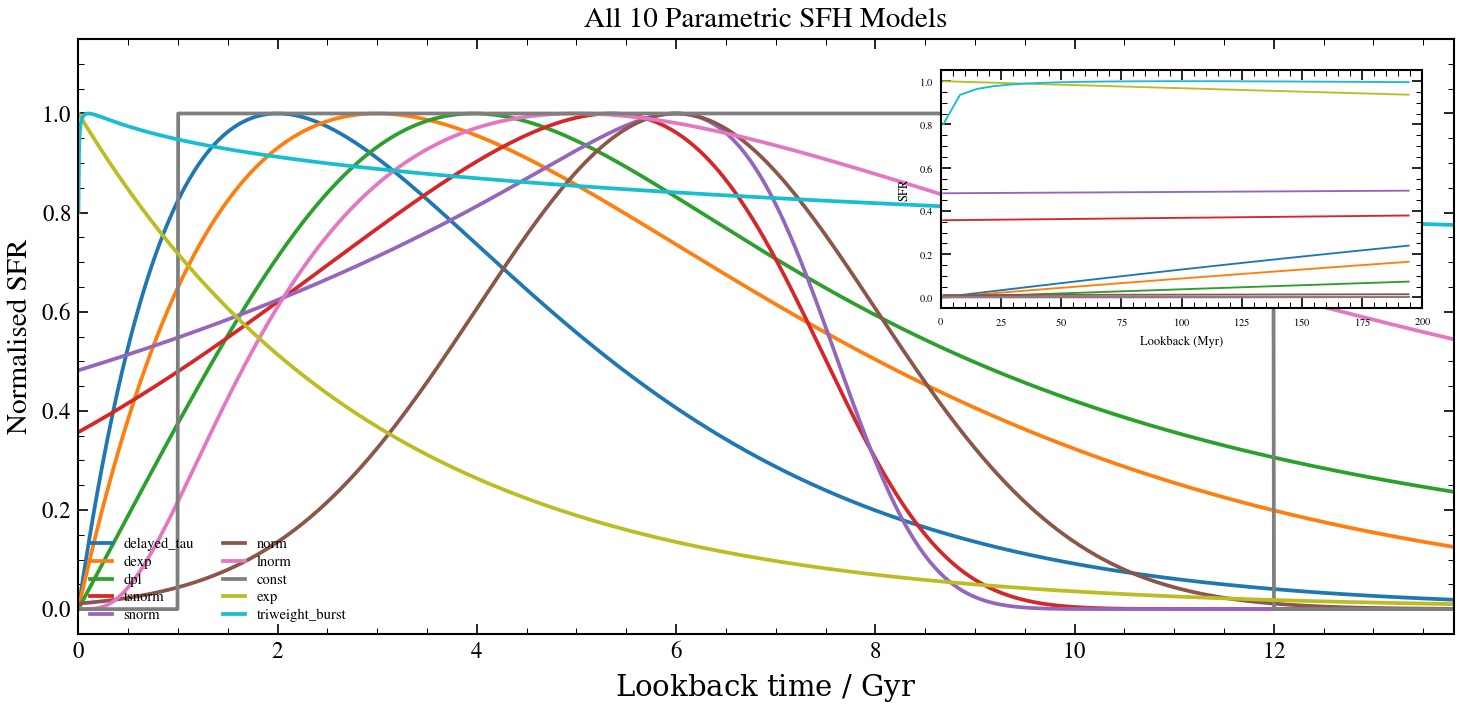

In [3]:
# --- FIGURE 1: All 10 parametric models ---
fig, ax = plt.subplots(figsize=(9, 4.5))

# A palette cycling through colorblind-safe colors
pal = plt.cm.tab10(np.linspace(0, 1, 10))

# 1. delayed_tau: SFR = norm * t * exp(-t/tau)
sfr_dtau = delayed_tau(t_yr, tau=2e9, norm=1.0)
sfr_dtau = sfr_dtau / np.max(sfr_dtau)
ax.plot(t_gyr, sfr_dtau, color=pal[0], lw=1.8, label="delayed_tau")

# 2. delayed_exponential (dexp): peaks at start + tau
sfr_dexp = delayed_exponential_sfh(t_yr, log_peak_sfr=0.0, tau=3e9, start=0.0)
sfr_dexp = sfr_dexp / np.max(sfr_dexp)
ax.plot(t_gyr, sfr_dexp, color=pal[1], lw=1.8, label="dexp")

# 3. double_powerlaw (dpl)
sfr_dpl = dpl(t_yr, alpha=2.0, beta=1.0, tau=5e9, log_peak_sfr=0.0)
sfr_dpl = sfr_dpl / np.max(sfr_dpl)
ax.plot(t_gyr, sfr_dpl, color=pal[2], lw=1.8, label="dpl")

# 4. tsnorm (Bellstedt+2020)
sfr_tsn = tsnorm(t_yr, log_peak_sfr=0.0, peak_lbt=6e9, width=2e9, skew=0.3, trunc=3.0)
sfr_tsn = sfr_tsn / np.max(sfr_tsn)
ax.plot(t_gyr, sfr_tsn, color=pal[3], lw=1.8, label="tsnorm")

# 5. snorm (skewed Gaussian)
sfr_sn = snorm(t_yr, log_peak_sfr=0.0, peak_lbt=6e9, width=2e9, skew=0.5)
sfr_sn = sfr_sn / np.max(sfr_sn)
ax.plot(t_gyr, sfr_sn, color=pal[4], lw=1.8, label="snorm")

# 6. norm (symmetric Gaussian)
sfr_nm = norm(t_yr, log_peak_sfr=0.0, peak_lbt=6e9, width=2e9)
sfr_nm = sfr_nm / np.max(sfr_nm)
ax.plot(t_gyr, sfr_nm, color=pal[5], lw=1.8, label="norm")

# 7. lnorm (log-normal)
sfr_ln = lnorm(t_yr, log_peak_sfr=0.0, peak_lbt=5e9, width=0.4)
sfr_ln = sfr_ln / np.max(sfr_ln)
ax.plot(t_gyr, sfr_ln, color=pal[6], lw=1.8, label="lnorm")

# 8. constant
sfr_cst = constant_sfh(t_yr, log_sfr=0.0, start=1e9, end=12e9)
sfr_cst = sfr_cst / np.max(sfr_cst + 1e-30)
ax.plot(t_gyr, sfr_cst, color=pal[7], lw=1.8, label="const")

# 9. exponential (declining tau)
sfr_exp = exponential_sfh(t_yr, log_peak_sfr=0.0, tau=3e9, start=0.0)
sfr_exp = sfr_exp / np.max(sfr_exp)
ax.plot(t_gyr, sfr_exp, color=pal[8], lw=1.8, label="exp")

# 10. triweight_burst
sfr_tw = triweight_burst(t_yr, log_tpeak_myr=2.0, log_tmax_myr=2.5)
sfr_tw = sfr_tw / np.max(sfr_tw + 1e-30)
ax.plot(t_gyr, sfr_tw, color=pal[9], lw=1.8, label="triweight_burst")

ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised SFR")
ax.set_title("All 10 Parametric SFH Models")
ax.legend(ncol=2, fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
ax.set_ylim(-0.05, 1.15)
add_multi_sfh_inset(
    ax,
    t_gyr,
    [sfr_dtau, sfr_dexp, sfr_dpl, sfr_tsn, sfr_sn, sfr_nm, sfr_ln, sfr_cst, sfr_exp, sfr_tw],
    colors=list(pal[:10]),
    lws=[0.9] * 10,
    ylabel="SFR",
)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_parametric_sfh_gallery.png"), bbox_inches="tight")
plt.show()

### 1.1 delayed_tau: varying $\tau$

$\text{SFR}(t) = N \cdot t \cdot \exp(-t/\tau)$. Peaks at $t = \tau$.

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/730635813.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


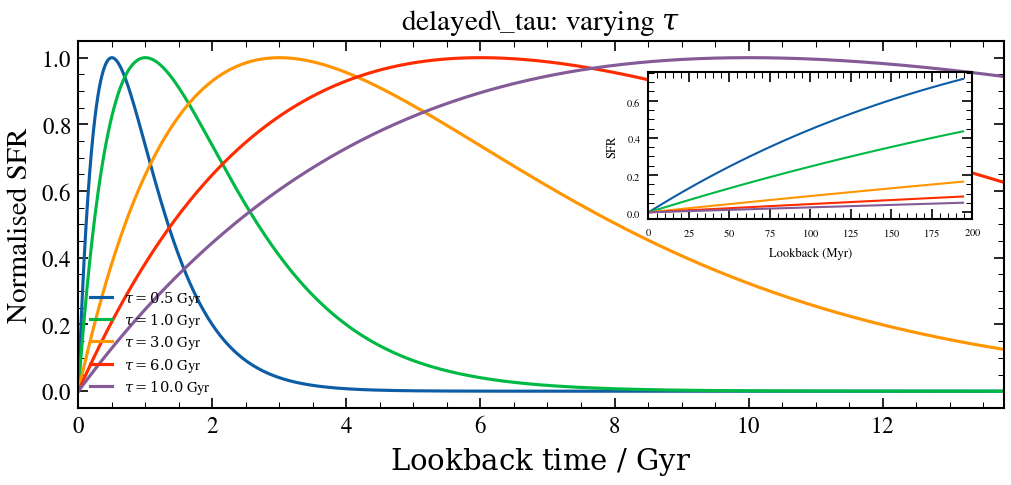

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
series_dtau = []
for tau_gyr in [0.5, 1.0, 3.0, 6.0, 10.0]:
    sfr = delayed_tau(t_yr, tau=tau_gyr * 1e9, norm=1.0)
    sfr = sfr / np.max(sfr)
    series_dtau.append(sfr)
    ax.plot(t_gyr, sfr, lw=1.5, label=rf"$\tau = {tau_gyr}$ Gyr")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised SFR")
ax.set_title(r"delayed\_tau: varying $\tau$")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, series_dtau, ylabel="SFR")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_delayed_tau_vary.png"), bbox_inches="tight")
plt.show()

### 1.2 delayed_exponential: varying $\tau$ and peak SFR

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/3267673433.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


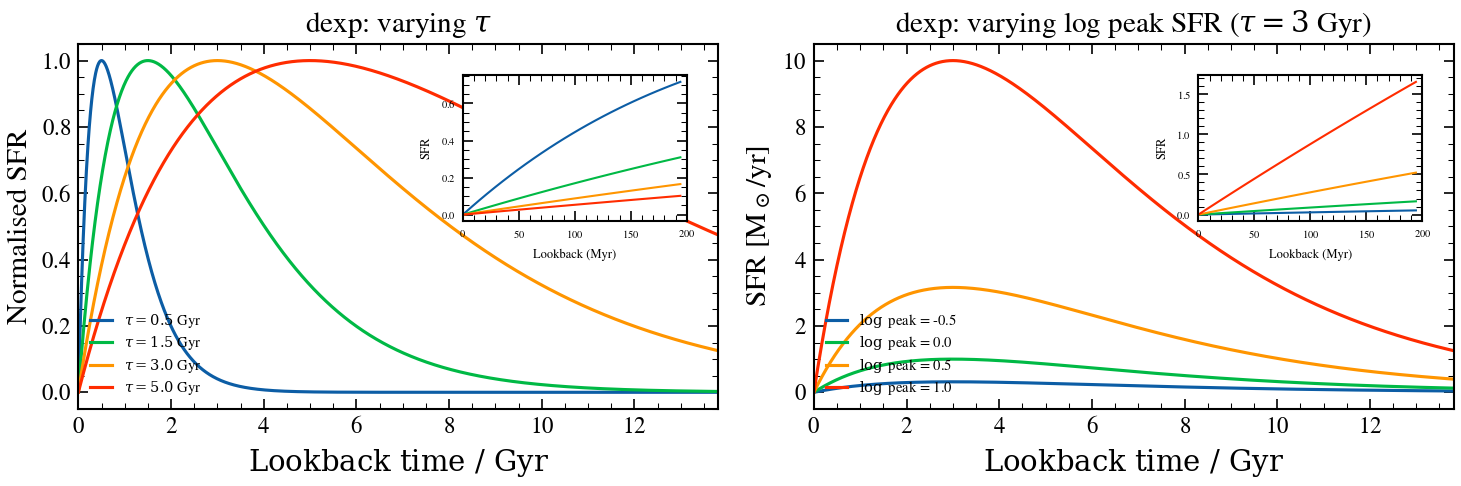

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

ax = axes[0]
series_dexp_tau = []
for tau_gyr in [0.5, 1.5, 3.0, 5.0]:
    sfr = delayed_exponential_sfh(t_yr, log_peak_sfr=0.0, tau=tau_gyr * 1e9)
    sfr = sfr / np.max(sfr)
    series_dexp_tau.append(sfr)
    ax.plot(t_gyr, sfr, lw=1.5, label=rf"$\tau = {tau_gyr}$ Gyr")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised SFR")
ax.set_title(r"dexp: varying $\tau$")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, series_dexp_tau, ylabel="SFR")

ax = axes[1]
series_dexp_lp = []
for log_p in [-0.5, 0.0, 0.5, 1.0]:
    sfr = delayed_exponential_sfh(t_yr, log_peak_sfr=log_p, tau=3e9)
    series_dexp_lp.append(sfr)
    ax.plot(t_gyr, sfr, lw=1.5, label=rf"$\log$ peak = {log_p}")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"SFR [M$_\odot$/yr]")
ax.set_title(r"dexp: varying log peak SFR ($\tau = 3$ Gyr)")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, series_dexp_lp, ylabel="SFR")

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_dexp_vary.png"), bbox_inches="tight")
plt.show()

### 1.3 Double Power Law (DPL): varying $\alpha$, $\beta$, $\tau$

$\text{SFR}(t) = \text{norm} / [(t/\tau)^\alpha + (t/\tau)^{-\beta}]$

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/1788511341.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


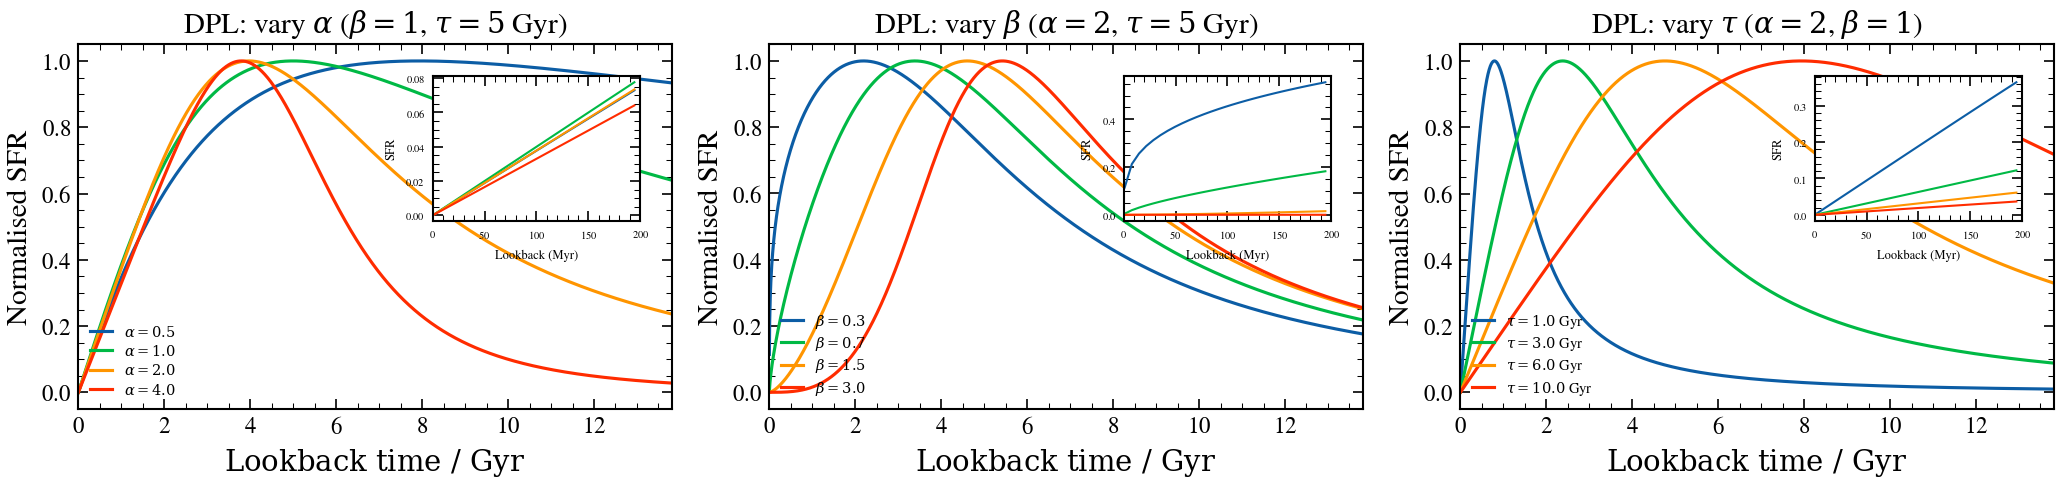

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Vary alpha (falling slope in cosmic time = decline from peak to present)
ax = axes[0]
series_dpl_a = []
for alpha in [0.5, 1.0, 2.0, 4.0]:
    sfr = dpl(t_yr, alpha=alpha, beta=1.0, tau=5e9, log_peak_sfr=0.0)
    sfr = sfr / np.max(sfr)
    series_dpl_a.append(sfr)
    ax.plot(t_gyr, sfr, lw=1.5, label=rf"$\alpha = {alpha}$")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised SFR")
ax.set_title(r"DPL: vary $\alpha$ ($\beta=1$, $\tau=5$ Gyr)")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, series_dpl_a, ylabel="SFR")

# Vary beta (rising slope in cosmic time)
ax = axes[1]
series_dpl_b = []
for beta in [0.3, 0.7, 1.5, 3.0]:
    sfr = dpl(t_yr, alpha=2.0, beta=beta, tau=5e9, log_peak_sfr=0.0)
    sfr = sfr / np.max(sfr)
    series_dpl_b.append(sfr)
    ax.plot(t_gyr, sfr, lw=1.5, label=rf"$\beta = {beta}$")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised SFR")
ax.set_title(r"DPL: vary $\beta$ ($\alpha=2$, $\tau=5$ Gyr)")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, series_dpl_b, ylabel="SFR")

# Vary tau (turnover time)
ax = axes[2]
series_dpl_t = []
for tau_gyr in [1.0, 3.0, 6.0, 10.0]:
    sfr = dpl(t_yr, alpha=2.0, beta=1.0, tau=tau_gyr * 1e9, log_peak_sfr=0.0)
    sfr = sfr / np.max(sfr)
    series_dpl_t.append(sfr)
    ax.plot(t_gyr, sfr, lw=1.5, label=rf"$\tau = {tau_gyr}$ Gyr")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised SFR")
ax.set_title(r"DPL: vary $\tau$ ($\alpha=2$, $\beta=1$)")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, series_dpl_t, ylabel="SFR")

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_dpl_vary.png"), bbox_inches="tight")
plt.show()

### 1.4 tsnorm (Bellstedt+2020): varying peak, width, skew, truncation

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/272472806.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


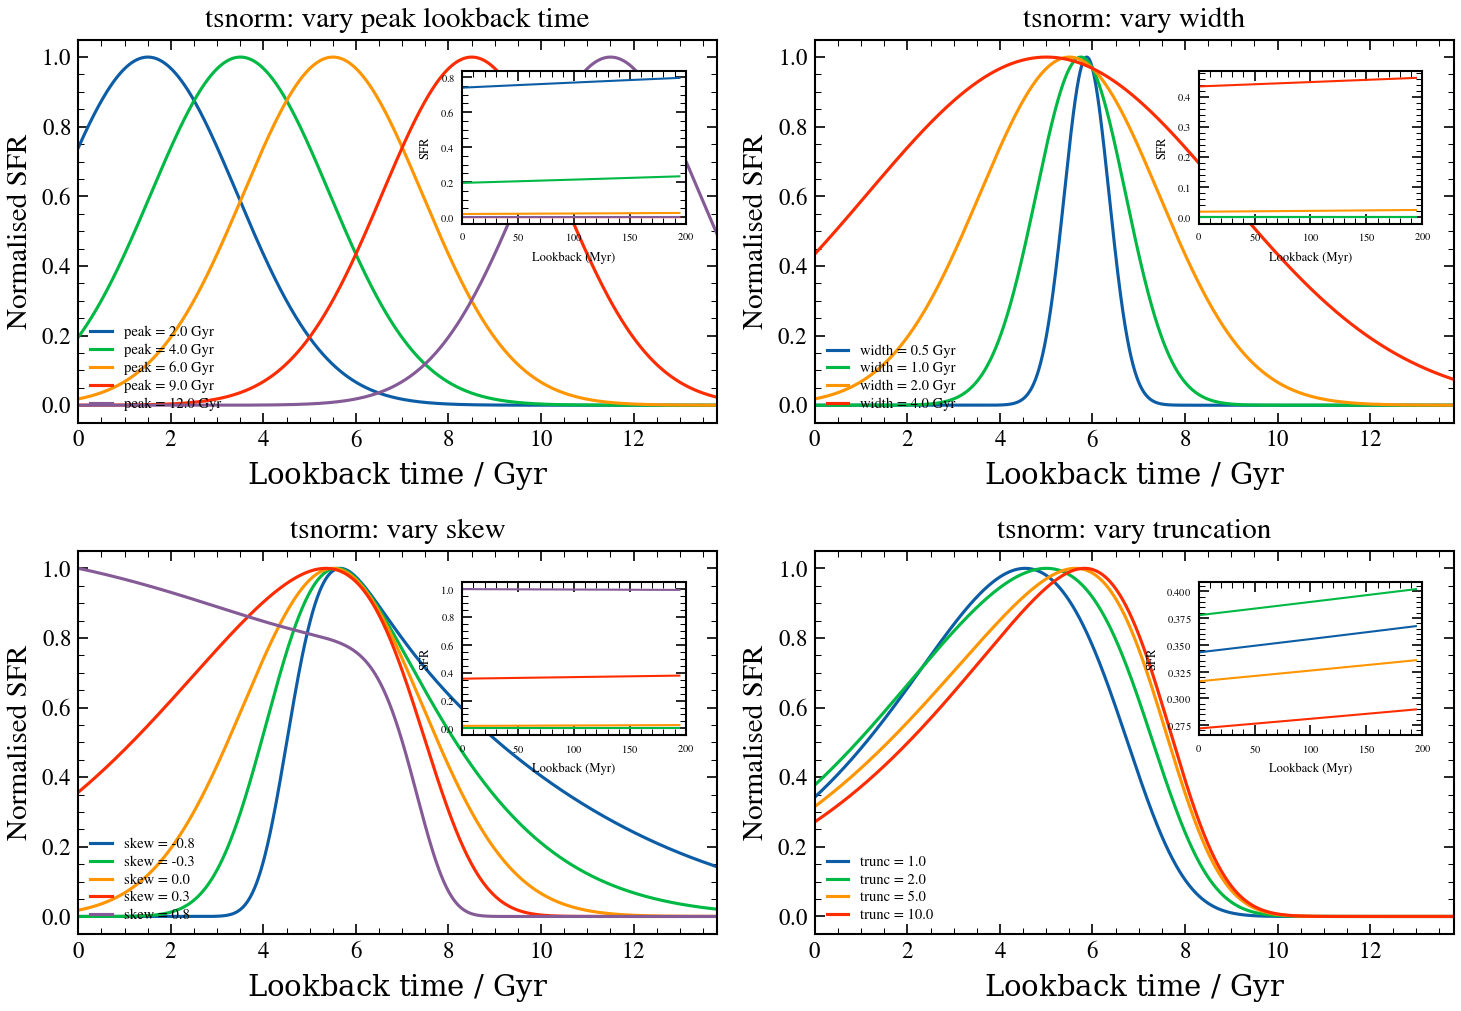

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# Vary peak lookback time
ax = axes[0, 0]
series_tsn_pk = []
for pk_gyr in [2.0, 4.0, 6.0, 9.0, 12.0]:
    sfr = tsnorm(t_yr, log_peak_sfr=0.0, peak_lbt=pk_gyr * 1e9, width=2e9, skew=0.0, trunc=3.0)
    sfr = sfr / np.max(sfr + 1e-30)
    series_tsn_pk.append(sfr)
    ax.plot(t_gyr, sfr, lw=1.5, label=rf"peak = {pk_gyr} Gyr")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised SFR")
ax.set_title("tsnorm: vary peak lookback time")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, series_tsn_pk, ylabel="SFR")

# Vary width
ax = axes[0, 1]
series_tsn_w = []
for w_gyr in [0.5, 1.0, 2.0, 4.0]:
    sfr = tsnorm(t_yr, log_peak_sfr=0.0, peak_lbt=6e9, width=w_gyr * 1e9, skew=0.0, trunc=3.0)
    sfr = sfr / np.max(sfr + 1e-30)
    series_tsn_w.append(sfr)
    ax.plot(t_gyr, sfr, lw=1.5, label=rf"width = {w_gyr} Gyr")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised SFR")
ax.set_title("tsnorm: vary width")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, series_tsn_w, ylabel="SFR")

# Vary skew
ax = axes[1, 0]
series_tsn_sk = []
for sk in [-0.8, -0.3, 0.0, 0.3, 0.8]:
    sfr = tsnorm(t_yr, log_peak_sfr=0.0, peak_lbt=6e9, width=2e9, skew=sk, trunc=3.0)
    sfr = sfr / np.max(sfr + 1e-30)
    series_tsn_sk.append(sfr)
    ax.plot(t_gyr, sfr, lw=1.5, label=rf"skew = {sk}")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised SFR")
ax.set_title("tsnorm: vary skew")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, series_tsn_sk, ylabel="SFR")

# Vary truncation
ax = axes[1, 1]
series_tsn_tr = []
for tr in [1.0, 2.0, 5.0, 10.0]:
    sfr = tsnorm(t_yr, log_peak_sfr=0.0, peak_lbt=6e9, width=2e9, skew=0.3, trunc=tr)
    sfr = sfr / np.max(sfr + 1e-30)
    series_tsn_tr.append(sfr)
    ax.plot(t_gyr, sfr, lw=1.5, label=rf"trunc = {tr}")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised SFR")
ax.set_title("tsnorm: vary truncation")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, series_tsn_tr, ylabel="SFR")

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_tsnorm_vary.png"), bbox_inches="tight")
plt.show()

### 1.5 snorm, norm, lnorm comparison

Three Gaussian-family models: snorm adds skewness, lnorm operates in
log-age space, norm is the simple symmetric case.

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/523929120.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


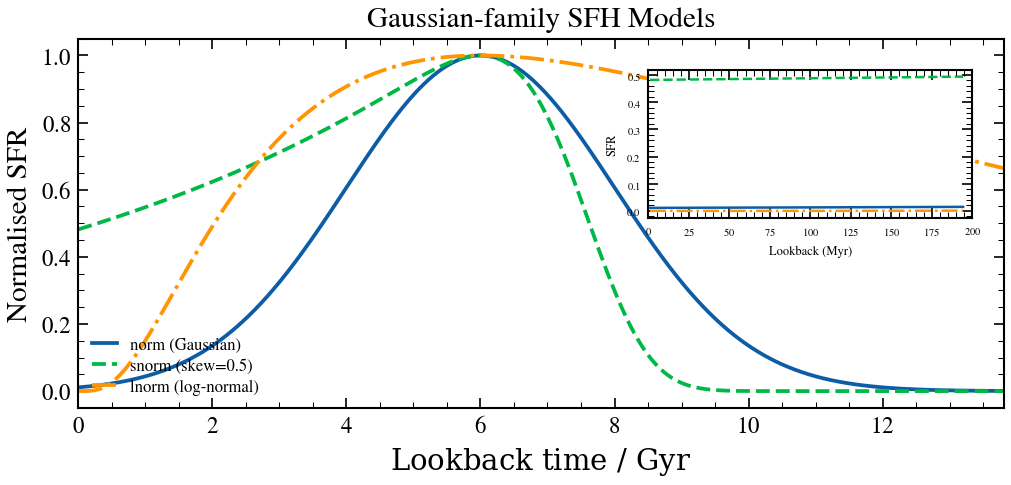

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))

sfr_norm = norm(t_yr, log_peak_sfr=0.0, peak_lbt=6e9, width=2e9)
sfr_snorm = snorm(t_yr, log_peak_sfr=0.0, peak_lbt=6e9, width=2e9, skew=0.5)
sfr_lnorm = lnorm(t_yr, log_peak_sfr=0.0, peak_lbt=6e9, width=0.4)

series_gauss = []
for sfr_i, name, ls in [
    (sfr_norm, "norm (Gaussian)", "-"),
    (sfr_snorm, "snorm (skew=0.5)", "--"),
    (sfr_lnorm, "lnorm (log-normal)", "-."),
]:
    sfr_i = sfr_i / np.max(sfr_i)
    series_gauss.append(sfr_i)
    ax.plot(t_gyr, sfr_i, lw=1.8, ls=ls, label=name)

ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised SFR")
ax.set_title("Gaussian-family SFH Models")
ax.legend(fontsize=8, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(
    ax, t_gyr, series_gauss, linestyles=["-", "--", "-."], lws=[1.2, 1.2, 1.2], ylabel="SFR"
)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_gaussian_family.png"), bbox_inches="tight")
plt.show()

### 1.6 constant and exponential

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/3698340690.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


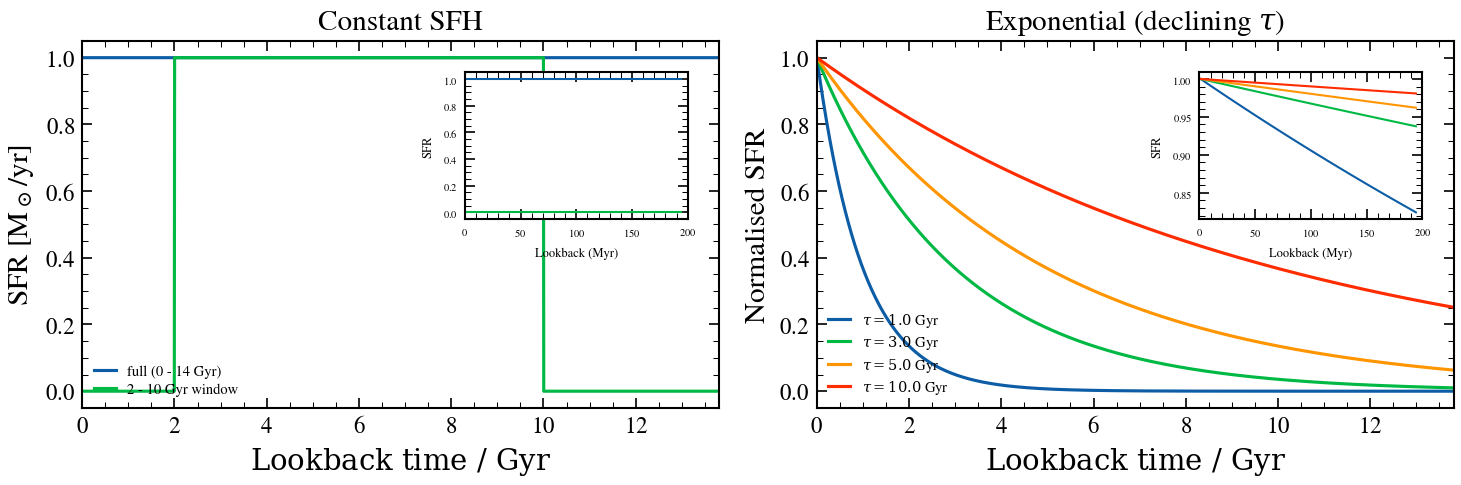

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

ax = axes[0]
sfr_c1 = constant_sfh(t_yr, log_sfr=0.0)
sfr_c2 = constant_sfh(t_yr, log_sfr=0.0, start=2e9, end=10e9)
ax.plot(t_gyr, np.array(sfr_c1), lw=1.5, label="full (0 - 14 Gyr)")
ax.plot(t_gyr, np.array(sfr_c2), lw=1.5, label="2 - 10 Gyr window")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"SFR [M$_\odot$/yr]")
ax.set_title("Constant SFH")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, [np.array(sfr_c1), np.array(sfr_c2)], ylabel="SFR")

ax = axes[1]
series_exp = []
for tau_gyr in [1.0, 3.0, 5.0, 10.0]:
    sfr = exponential_sfh(t_yr, log_peak_sfr=0.0, tau=tau_gyr * 1e9)
    sfr = sfr / np.max(sfr)
    series_exp.append(sfr)
    ax.plot(t_gyr, sfr, lw=1.5, label=rf"$\tau = {tau_gyr}$ Gyr")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised SFR")
ax.set_title(r"Exponential (declining $\tau$)")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, series_exp, ylabel="SFR")

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_const_exp.png"), bbox_inches="tight")
plt.show()

### 1.7 triweight_burst: compact burst kernel

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/3924623693.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


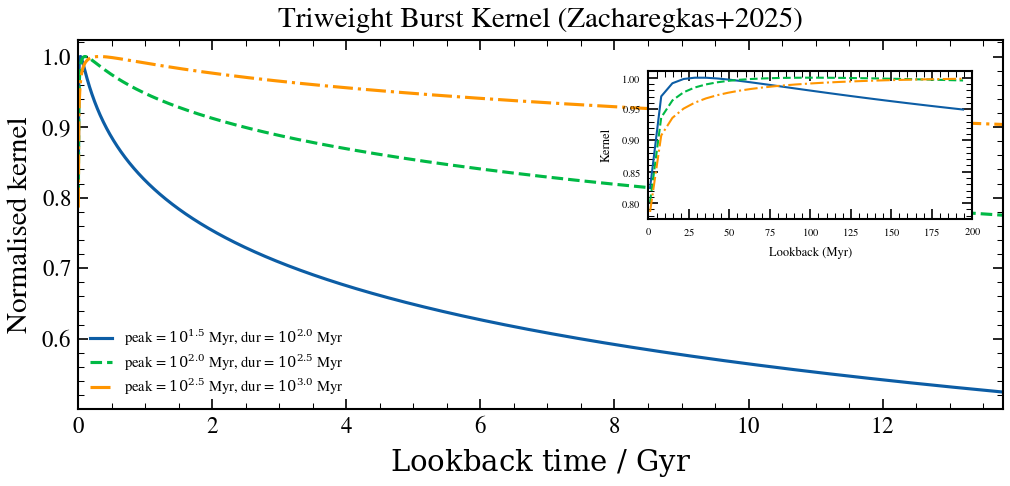

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
series_tw = []
lss = []
for tp, tw, ls in [(1.5, 2.0, "-"), (2.0, 2.5, "--"), (2.5, 3.0, "-.")]:
    sfr = triweight_burst(t_yr, log_tpeak_myr=tp, log_tmax_myr=tw)
    sfr = sfr / np.max(sfr + 1e-30)
    series_tw.append(sfr)
    lss.append(ls)
    ax.plot(t_gyr, sfr, lw=1.5, ls=ls, label=rf"peak = $10^{{{tp}}}$ Myr, dur = $10^{{{tw}}}$ Myr")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel("Normalised kernel")
ax.set_title("Triweight Burst Kernel (Zacharegkas+2025)")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(ax, t_gyr, series_tw, linestyles=lss, ylabel="Kernel")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_triweight_burst.png"), bbox_inches="tight")
plt.show()

## 2. Non-Parametric SFH Models

### 2.1 Continuity SFH (Leja+2019)

Free parameters are log-SFR ratios between adjacent bins. A Student-t
smoothness prior penalises sharp jumps.

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/1570037714.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


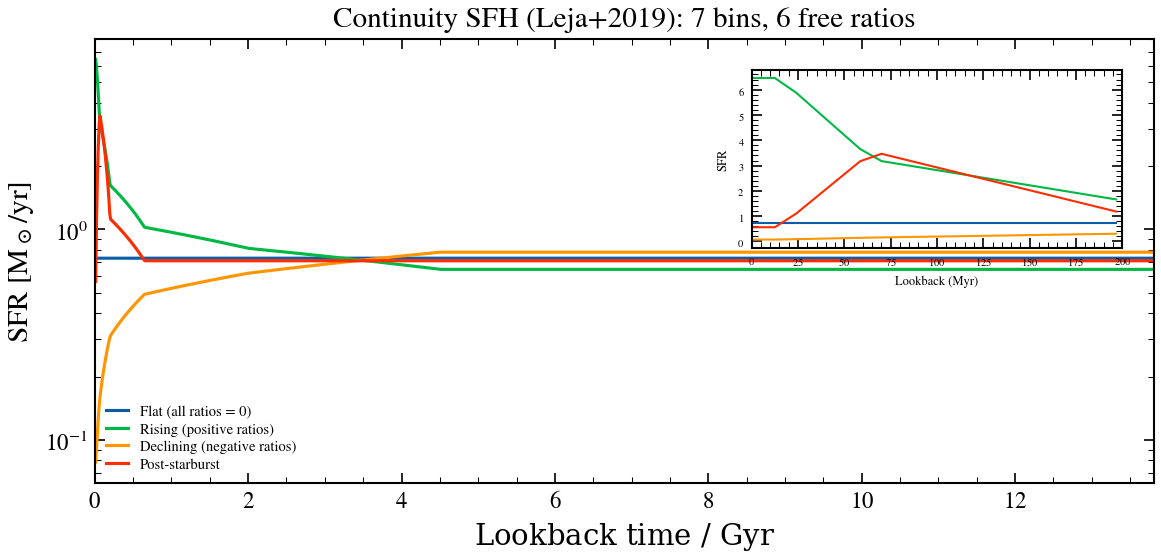

In [11]:
age_yr = np.linspace(10**6.0, 10**10.14, 1200)
age_gyr = age_yr / 1e9

fig, ax = plt.subplots(figsize=(6.5, 3.2))

# Scenario A: Flat SFH (all ratios = 0)
sfr_flat = continuity_sfh(
    jnp.array(age_yr),
    log_total_mass=10.0,
    ratio_0=0.0,
    ratio_1=0.0,
    ratio_2=0.0,
    ratio_3=0.0,
    ratio_4=0.0,
    ratio_5=0.0,
)
ax.plot(age_gyr, np.array(sfr_flat), lw=1.5, label="Flat (all ratios = 0)")

# Scenario B: Rising SFH (positive ratios = younger bins have higher SFR)
sfr_rise = continuity_sfh(
    jnp.array(age_yr),
    log_total_mass=10.0,
    ratio_0=0.3,
    ratio_1=0.3,
    ratio_2=0.2,
    ratio_3=0.1,
    ratio_4=0.1,
    ratio_5=0.0,
)
ax.plot(age_gyr, np.array(sfr_rise), lw=1.5, label="Rising (positive ratios)")

# Scenario C: Declining SFH (negative ratios)
sfr_dec = continuity_sfh(
    jnp.array(age_yr),
    log_total_mass=10.0,
    ratio_0=-0.3,
    ratio_1=-0.3,
    ratio_2=-0.2,
    ratio_3=-0.1,
    ratio_4=-0.1,
    ratio_5=0.0,
)
ax.plot(age_gyr, np.array(sfr_dec), lw=1.5, label="Declining (negative ratios)")

# Scenario D: Post-starburst (one sharp dip)
sfr_psb = continuity_sfh(
    jnp.array(age_yr),
    log_total_mass=10.0,
    ratio_0=-0.8,
    ratio_1=0.5,
    ratio_2=0.2,
    ratio_3=0.0,
    ratio_4=0.0,
    ratio_5=0.0,
)
ax.plot(age_gyr, np.array(sfr_psb), lw=1.5, label="Post-starburst")

ax.set_yscale("log")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"SFR [M$_\odot$/yr]")
ax.set_title("Continuity SFH (Leja+2019): 7 bins, 6 free ratios")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(age_gyr[-1]))
add_multi_sfh_inset(
    ax,
    age_gyr,
    [np.array(sfr_flat), np.array(sfr_rise), np.array(sfr_dec), np.array(sfr_psb)],
    ylabel="SFR",
)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_continuity_sfh.png"), bbox_inches="tight")
plt.show()

### 2.2 Dirichlet SFH (Leja+2017)

Mass fractions in each bin are derived from auxiliary variables via
stick-breaking. Uniform auxiliary variables $z_i \in (0, 1)$ give a
symmetric Dirichlet(1,...,1) prior.

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/4130738636.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


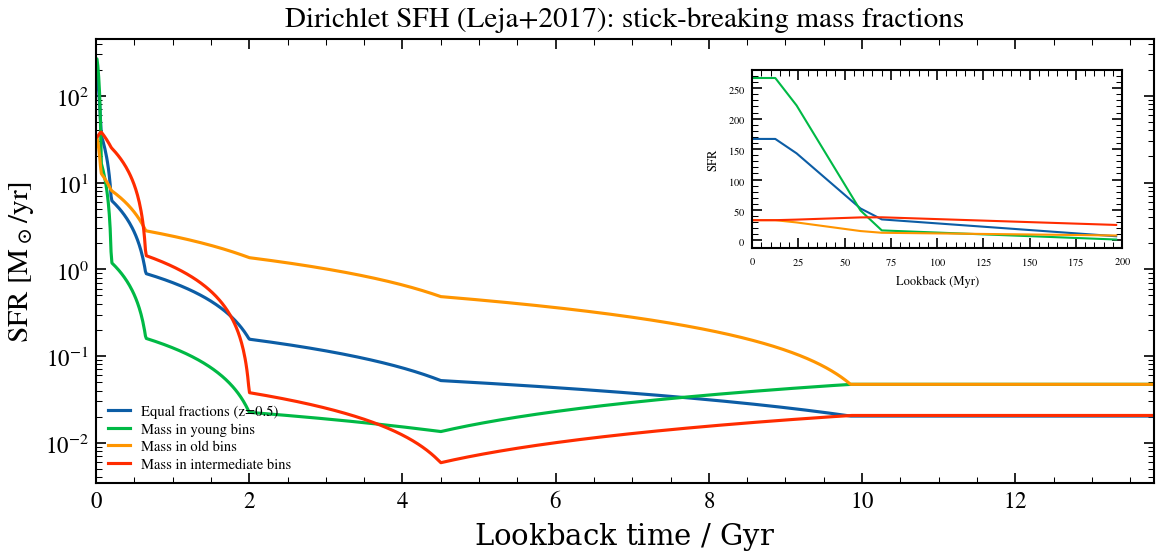

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))

# Uniform mass fraction (all z = 0.5 => roughly equal fractions)
sfr_unif = dirichlet_sfh(
    jnp.array(age_yr),
    log_total_mass=10.0,
    z_frac_0=0.5,
    z_frac_1=0.5,
    z_frac_2=0.5,
    z_frac_3=0.5,
    z_frac_4=0.5,
    z_frac_5=0.5,
)
ax.plot(age_gyr, np.array(sfr_unif), lw=1.5, label="Equal fractions (z=0.5)")

# Mass concentrated in young bins
sfr_young = dirichlet_sfh(
    jnp.array(age_yr),
    log_total_mass=10.0,
    z_frac_0=0.8,
    z_frac_1=0.6,
    z_frac_2=0.3,
    z_frac_3=0.2,
    z_frac_4=0.1,
    z_frac_5=0.1,
)
ax.plot(age_gyr, np.array(sfr_young), lw=1.5, label="Mass in young bins")

# Mass concentrated in old bins
sfr_old = dirichlet_sfh(
    jnp.array(age_yr),
    log_total_mass=10.0,
    z_frac_0=0.1,
    z_frac_1=0.1,
    z_frac_2=0.2,
    z_frac_3=0.3,
    z_frac_4=0.6,
    z_frac_5=0.8,
)
ax.plot(age_gyr, np.array(sfr_old), lw=1.5, label="Mass in old bins")

# Mass in intermediate bins
sfr_mid = dirichlet_sfh(
    jnp.array(age_yr),
    log_total_mass=10.0,
    z_frac_0=0.1,
    z_frac_1=0.3,
    z_frac_2=0.8,
    z_frac_3=0.8,
    z_frac_4=0.3,
    z_frac_5=0.1,
)
ax.plot(age_gyr, np.array(sfr_mid), lw=1.5, label="Mass in intermediate bins")

ax.set_yscale("log")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"SFR [M$_\odot$/yr]")
ax.set_title("Dirichlet SFH (Leja+2017): stick-breaking mass fractions")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(age_gyr[-1]))
add_multi_sfh_inset(
    ax,
    age_gyr,
    [
        np.array(sfr_unif),
        np.array(sfr_young),
        np.array(sfr_old),
        np.array(sfr_mid),
    ],
    ylabel="SFR",
)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_dirichlet_sfh.png"), bbox_inches="tight")
plt.show()

## 3. Stochastic (GP) SFH Model

The GP modulates a smooth mean SFH:
$\text{SFR}(t) = \bar{\text{SFR}}(t) \cdot \exp\!\bigl(x(t) - K(0)/2\bigr)$
where $x(t) \sim \mathcal{GP}(0, P(\omega))$.

### 3.1 Mean SFH + GP Modulation

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/3607373573.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


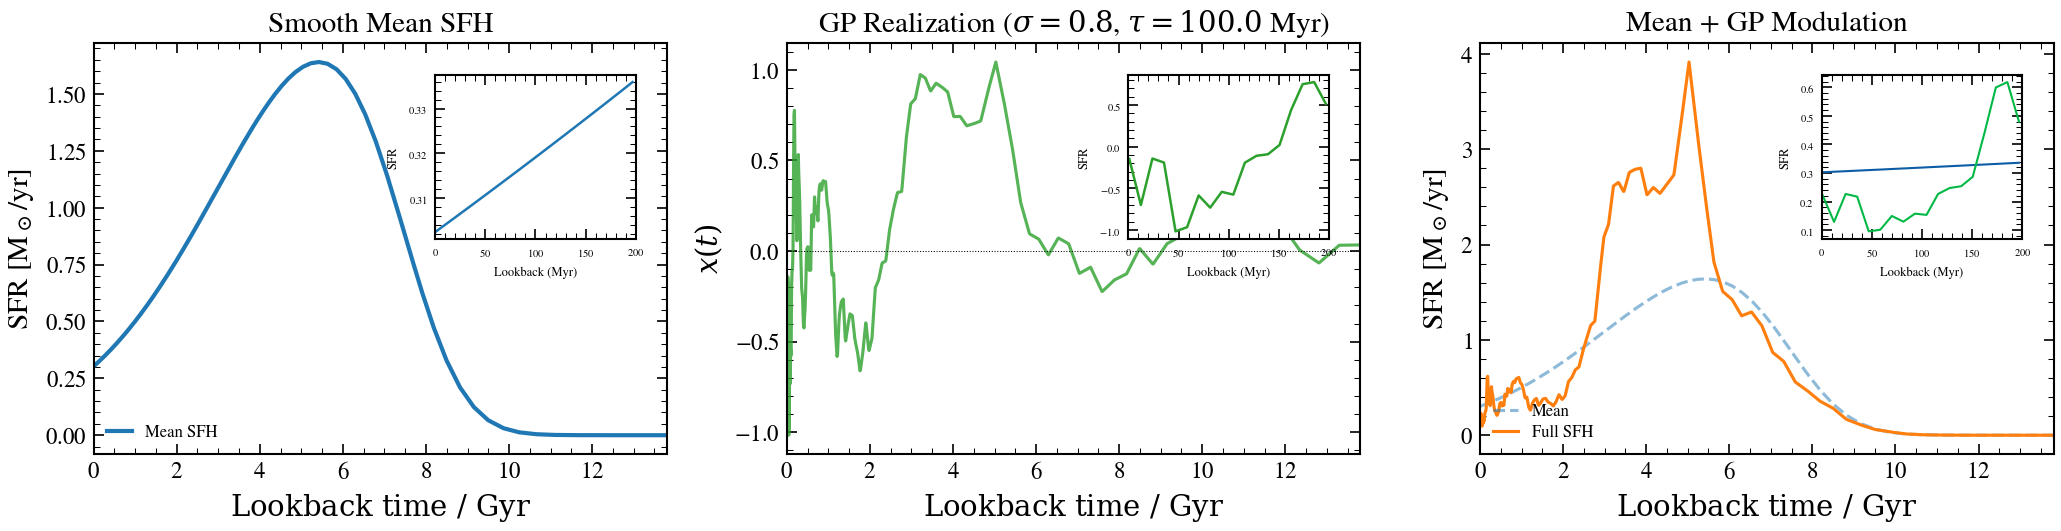

In [13]:
N_GRID = 256
log_ages = make_log_age_grid(N_GRID)
d_log_age = grid_spacing(log_ages)
ages_yr = 10**log_ages
ages_yr_arr = np.array(ages_yr)
ages_yr_lin = np.linspace(float(ages_yr_arr[0]), float(ages_yr_arr[-1]), 1200)
ages_gyr_lin = ages_yr_lin / 1e9


def _sfh_on_lin_grid(y):
    return np.interp(ages_yr_lin, ages_yr_arr, np.asarray(y).ravel())


key = jax.random.PRNGKey(42)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))

# Panel A: Mean SFH (tsnorm)
ax = axes[0]
mean_sfr = tsnorm(ages_yr, log_peak_sfr=0.5, peak_lbt=6e9, width=2e9, skew=0.2, trunc=3.0)
mean_lin = _sfh_on_lin_grid(mean_sfr)
ax.plot(ages_gyr_lin, mean_lin, color=COLORS["sfh_mean"], lw=2, label="Mean SFH")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"SFR [M$_\odot$/yr]")
ax.set_title("Smooth Mean SFH")
ax.legend(fontsize=8, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(ages_gyr_lin[-1]))
add_sfh_inset(ax, ages_gyr_lin, mean_lin, color=COLORS["sfh_mean"], lw=1.2)

# Panel B: GP realization
ax = axes[1]
sigma, tau_myr = 0.8, 100.0
sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, tau_myr * 1e6)
gp = generate_gp_fourier(key, sqrt_p, N_GRID)
k0_half = float(drw_variance(sigma)) / 2.0
gp_lin = _sfh_on_lin_grid(gp)
ax.plot(ages_gyr_lin, gp_lin, color=COLORS["sfh_gp"], lw=1.5, alpha=0.8)
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"$x(t)$")
ax.set_title(rf"GP Realization ($\sigma={sigma}$, $\tau={tau_myr}$ Myr)")
ax.set_xlim(0.0, float(ages_gyr_lin[-1]))
add_sfh_inset(ax, ages_gyr_lin, gp_lin, color=COLORS["sfh_gp"], lw=1.2)

# Panel C: Full stochastic SFH
ax = axes[2]
full_sfr = mean_sfr * jnp.exp(gp - k0_half)
full_lin = _sfh_on_lin_grid(full_sfr)
ax.plot(ages_gyr_lin, mean_lin, color=COLORS["sfh_mean"], lw=1.5, alpha=0.5, label="Mean", ls="--")
ax.plot(ages_gyr_lin, full_lin, color=COLORS["sfh_full"], lw=1.5, label="Full SFH")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"SFR [M$_\odot$/yr]")
ax.set_title("Mean + GP Modulation")
ax.legend(fontsize=8, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(ages_gyr_lin[-1]))
add_multi_sfh_inset(ax, ages_gyr_lin, [mean_lin, full_lin], ylabel="SFR")

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_gp_sfh_demo.png"), bbox_inches="tight")
plt.show()

### 3.2 DRW PSD: varying $\sigma_{\rm PS}$ and $\tau_{\rm PS}$

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/3649220247.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


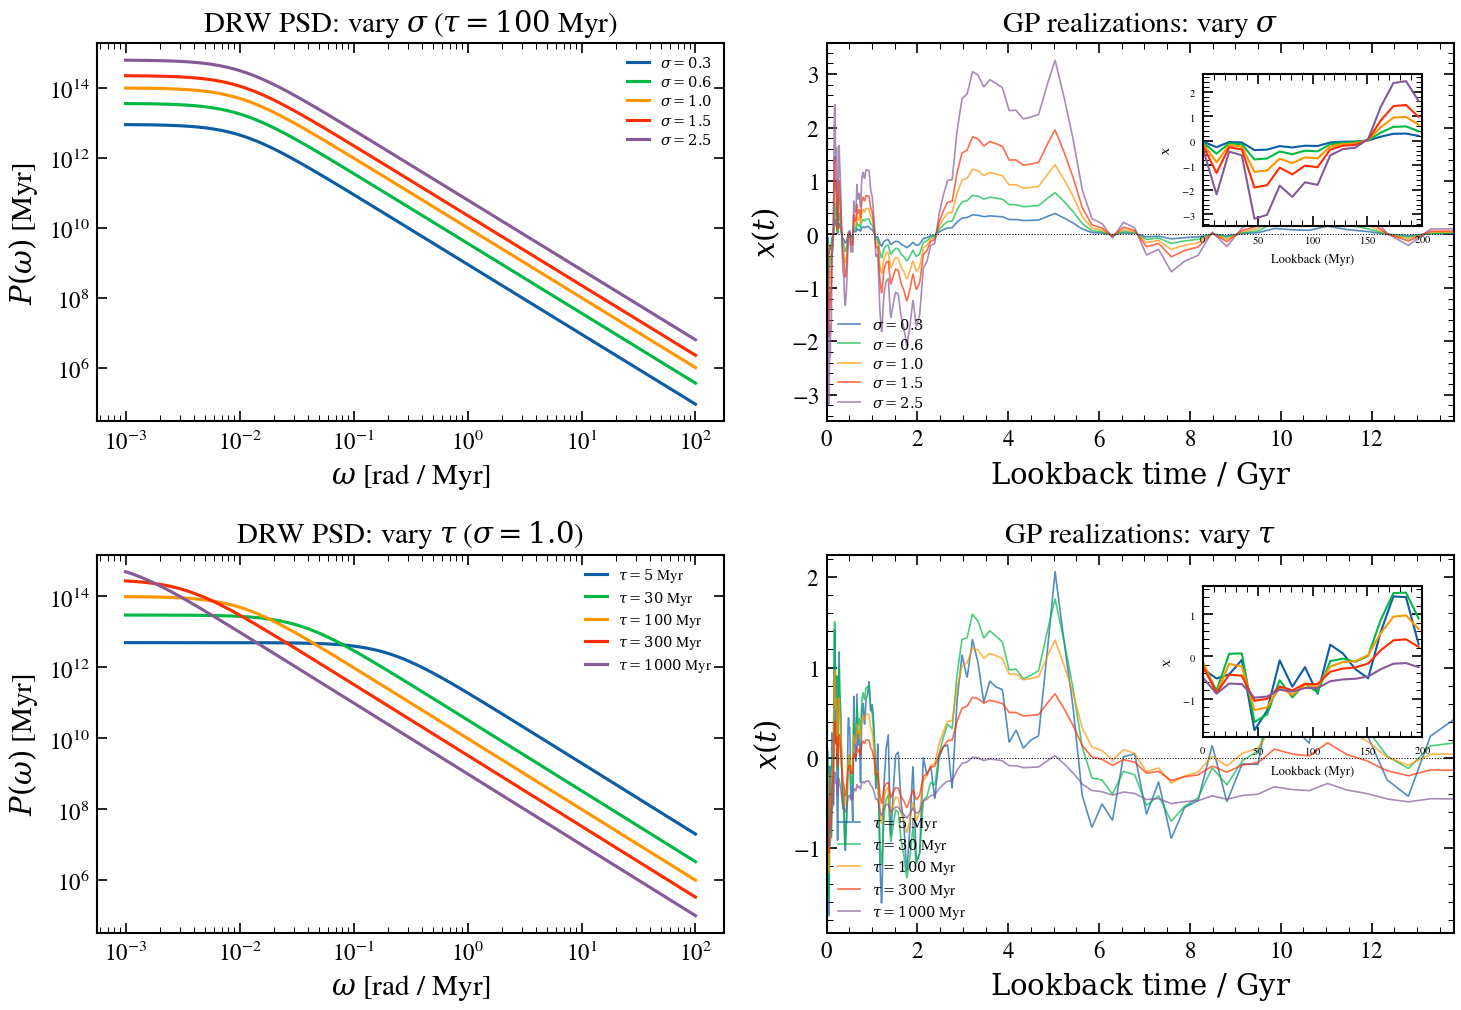

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# Top row: vary sigma
sigmas = [0.3, 0.6, 1.0, 1.5, 2.5]
ax = axes[0, 0]
omega = np.logspace(-3, 2, 500)  # rad / Myr
for sig in sigmas:
    psd = psd_drw(omega / 1e6, sig, 100e6)  # convert to rad/yr
    ax.loglog(omega, psd * 1e6, lw=1.5, label=rf"$\sigma = {sig}$")
ax.set_xlabel(r"$\omega$ [rad / Myr]")
ax.set_ylabel(r"$P(\omega)$ [Myr]")
ax.set_title(r"DRW PSD: vary $\sigma$ ($\tau=100$ Myr)")
ax.legend(fontsize=7, frameon=False)

ax = axes[0, 1]
series_gp_sig = []
for sig in sigmas:
    sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sig, 100e6)
    gp_i = generate_gp_fourier(key, sqrt_p, N_GRID)
    gpl = _sfh_on_lin_grid(gp_i)
    series_gp_sig.append(gpl)
    ax.plot(ages_gyr_lin, gpl, lw=0.8, alpha=0.7, label=rf"$\sigma = {sig}$")
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"$x(t)$")
ax.set_title(r"GP realizations: vary $\sigma$")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(ages_gyr_lin[-1]))
add_multi_sfh_inset(ax, ages_gyr_lin, series_gp_sig, ylabel=r"$x$")

# Bottom row: vary tau
taus_myr = [5, 30, 100, 300, 1000]
ax = axes[1, 0]
for tau in taus_myr:
    psd = psd_drw(omega / 1e6, 1.0, tau * 1e6)
    ax.loglog(omega, psd * 1e6, lw=1.5, label=rf"$\tau = {tau}$ Myr")
ax.set_xlabel(r"$\omega$ [rad / Myr]")
ax.set_ylabel(r"$P(\omega)$ [Myr]")
ax.set_title(r"DRW PSD: vary $\tau$ ($\sigma=1.0$)")
ax.legend(fontsize=7, frameon=False)

ax = axes[1, 1]
series_gp_tau = []
for tau in taus_myr:
    sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, 1.0, tau * 1e6)
    gp_i = generate_gp_fourier(key, sqrt_p, N_GRID)
    gpl = _sfh_on_lin_grid(gp_i)
    series_gp_tau.append(gpl)
    ax.plot(ages_gyr_lin, gpl, lw=0.8, alpha=0.7, label=rf"$\tau = {tau}$ Myr")
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"$x(t)$")
ax.set_title(r"GP realizations: vary $\tau$")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(ages_gyr_lin[-1]))
add_multi_sfh_inset(ax, ages_gyr_lin, series_gp_tau, ylabel=r"$x$")

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_drw_psd_vary.png"), bbox_inches="tight")
plt.show()

### 3.3 Extended Regulator PSD (Tacchella+2020)

Two-timescale PSD: regulator (gas inflow/equilibrium) + dynamical term.

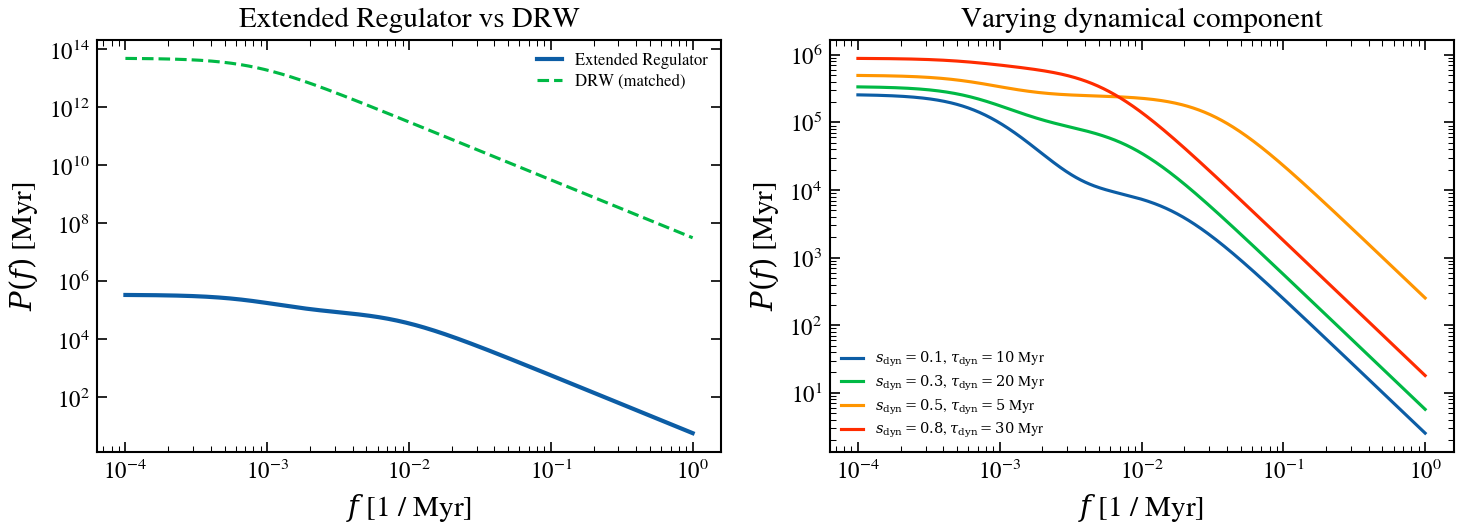

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))

f_myr = np.logspace(-4, 0, 500)  # cyclic frequency (1/Myr)

ax = axes[0]
# Fiducial extended regulator
psd_er = psd_extended_regulator(
    f_myr / 1e6, s_reg=0.5, tau_in=200e6, tau_eq=50e6, s_dyn=0.3, tau_dyn=20e6
)
psd_simple = psd_drw(2 * np.pi * f_myr / 1e6, 0.5, 200e6)
ax.loglog(f_myr, psd_er * 1e6, lw=2, label="Extended Regulator")
ax.loglog(f_myr, psd_simple * 1e6, lw=1.5, ls="--", label="DRW (matched)")
ax.set_xlabel(r"$f$ [1 / Myr]")
ax.set_ylabel(r"$P(f)$ [Myr]")
ax.set_title("Extended Regulator vs DRW")
ax.legend(fontsize=8, frameon=False)

# Panel B: Vary dynamical term
ax = axes[1]
for s_dyn, tau_dyn in [(0.1, 10e6), (0.3, 20e6), (0.5, 5e6), (0.8, 30e6)]:
    psd_i = psd_extended_regulator(
        f_myr / 1e6, s_reg=0.5, tau_in=200e6, tau_eq=50e6, s_dyn=s_dyn, tau_dyn=tau_dyn
    )
    td_myr = tau_dyn / 1e6
    ax.loglog(
        f_myr,
        psd_i * 1e6,
        lw=1.5,
        label=rf"$s_{{\rm dyn}}={s_dyn}$, $\tau_{{\rm dyn}}={td_myr:.0f}$ Myr",
    )
ax.set_xlabel(r"$f$ [1 / Myr]")
ax.set_ylabel(r"$P(f)$ [Myr]")
ax.set_title("Varying dynamical component")
ax.legend(fontsize=7, frameon=False)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_extended_regulator.png"), bbox_inches="tight")
plt.show()

### 3.4 Matern PSD: varying $\nu$

$\nu = 0.5$ recovers the DRW. Higher $\nu$ damps high-frequency
fluctuations more strongly, giving smoother GP realizations.

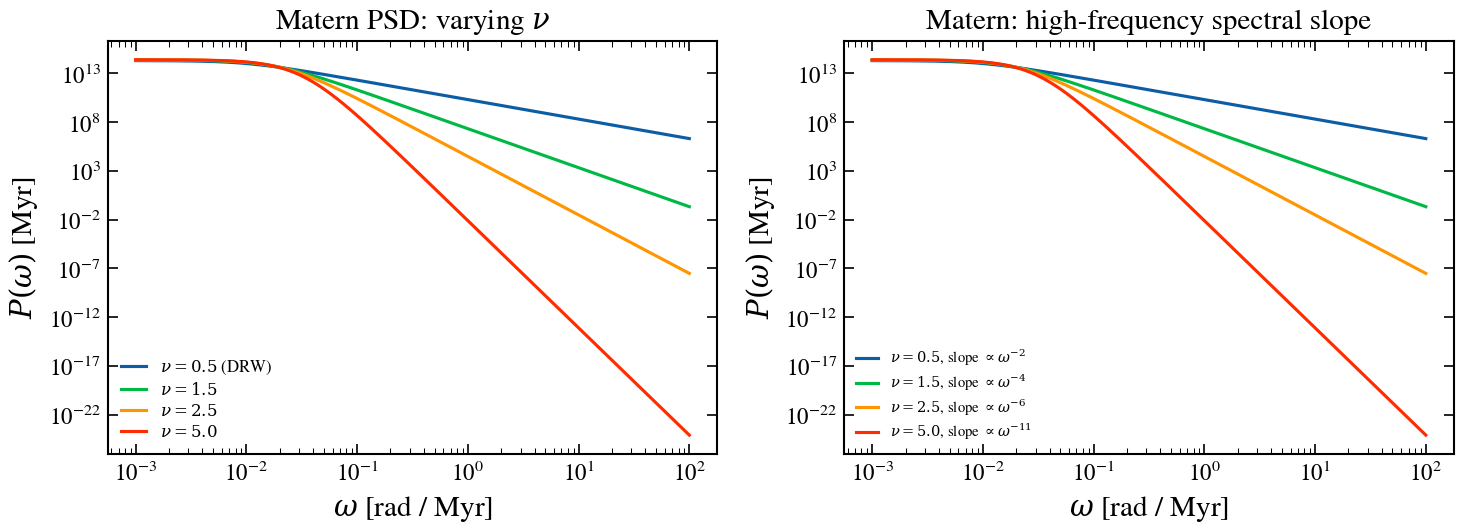

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))

omega_rad_yr = np.logspace(-9, -4, 500)  # rad/yr

ax = axes[0]
for nu in [0.5, 1.5, 2.5, 5.0]:
    psd_m = psd_matern(omega_rad_yr, variance=1.0, length_scale=100e6, nu=nu)
    label_str = r"$\nu = 0.5$ (DRW)" if nu == 0.5 else rf"$\nu = {nu}$"
    ax.loglog(omega_rad_yr * 1e6, psd_m * 1e6, lw=1.5, label=label_str)
ax.set_xlabel(r"$\omega$ [rad / Myr]")
ax.set_ylabel(r"$P(\omega)$ [Myr]")
ax.set_title(r"Matern PSD: varying $\nu$")
ax.legend(fontsize=8, frameon=False)

# Note on high-frequency slopes
ax = axes[1]
for nu in [0.5, 1.5, 2.5, 5.0]:
    psd_m = psd_matern(omega_rad_yr, variance=1.0, length_scale=100e6, nu=nu)
    slope = -(2 * nu + 1)
    label_str = rf"$\nu = {nu}$, slope $\propto \omega^{{{slope:.0f}}}$"
    ax.loglog(omega_rad_yr * 1e6, psd_m * 1e6, lw=1.5, label=label_str)
ax.set_xlabel(r"$\omega$ [rad / Myr]")
ax.set_ylabel(r"$P(\omega)$ [Myr]")
ax.set_title("Matern: high-frequency spectral slope")
ax.legend(fontsize=7, frameon=False)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_matern_psd.png"), bbox_inches="tight")
plt.show()

## 4. Composition System

The SFH registry supports three composition types:
- **additive**: sum of smooth components (e.g., tsnorm + const)
- **mixture**: smooth base with burst admixture (e.g., tsnorm + burst)
- **modulator**: multiplicative GP field (e.g., tsnorm + field)

### 4.1 Additive: DPL + constant

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/2311975451.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


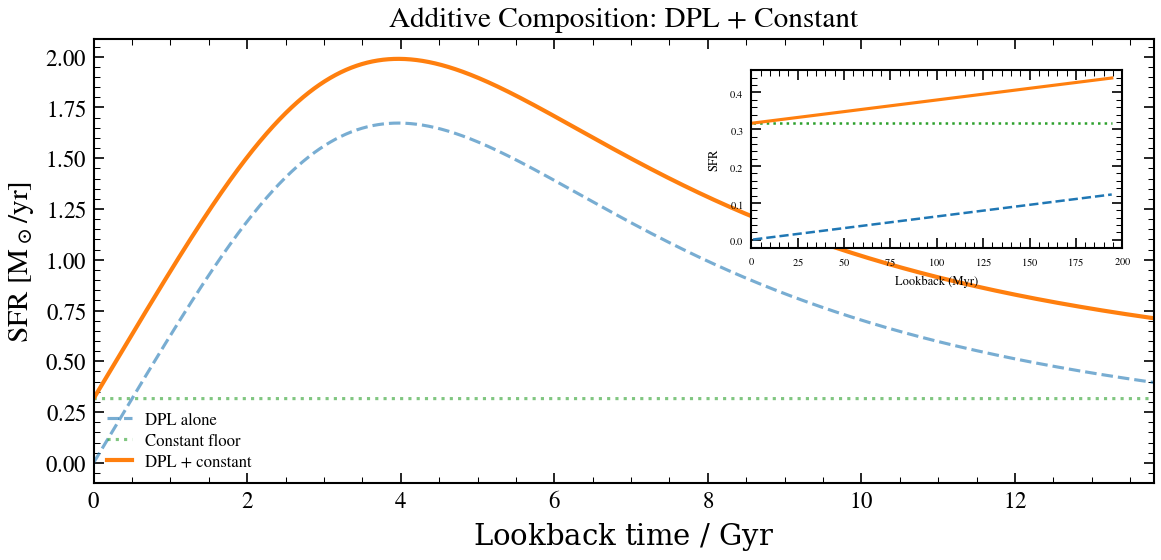

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))

sfr_dpl_only = dpl(t_yr, alpha=2.0, beta=1.0, tau=5e9, log_peak_sfr=0.5)
sfr_const_part = constant_sfh(t_yr, log_sfr=-0.5)
sfr_sum = np.array(sfr_dpl_only) + np.array(sfr_const_part)

ax.plot(
    t_gyr,
    np.array(sfr_dpl_only),
    ls="--",
    lw=1.5,
    color=COLORS["sfh_mean"],
    label="DPL alone",
    alpha=0.6,
)
ax.plot(
    t_gyr,
    np.array(sfr_const_part),
    ls=":",
    lw=1.5,
    color=COLORS["sfh_gp"],
    label="Constant floor",
    alpha=0.6,
)
ax.plot(t_gyr, sfr_sum, lw=2, color=COLORS["sfh_full"], label="DPL + constant")

ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"SFR [M$_\odot$/yr]")
ax.set_title("Additive Composition: DPL + Constant")
ax.legend(fontsize=8, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(t_gyr[-1]))
add_multi_sfh_inset(
    ax,
    t_gyr,
    [np.array(sfr_dpl_only), np.array(sfr_const_part), sfr_sum],
    colors=[COLORS["sfh_mean"], COLORS["sfh_gp"], COLORS["sfh_full"]],
    linestyles=["--", ":", "-"],
    lws=[1.2, 1.2, 1.5],
    ylabel="SFR",
)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_composition_additive.png"), bbox_inches="tight")
plt.show()

### 4.2 Burst Mixture: smooth + triweight burst

$\text{SFR}(t) = (1 - f_{\rm burst}) \cdot \text{smooth}(t)
  + f_{\rm burst} \cdot \text{burst}(t)$

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/2508278635.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


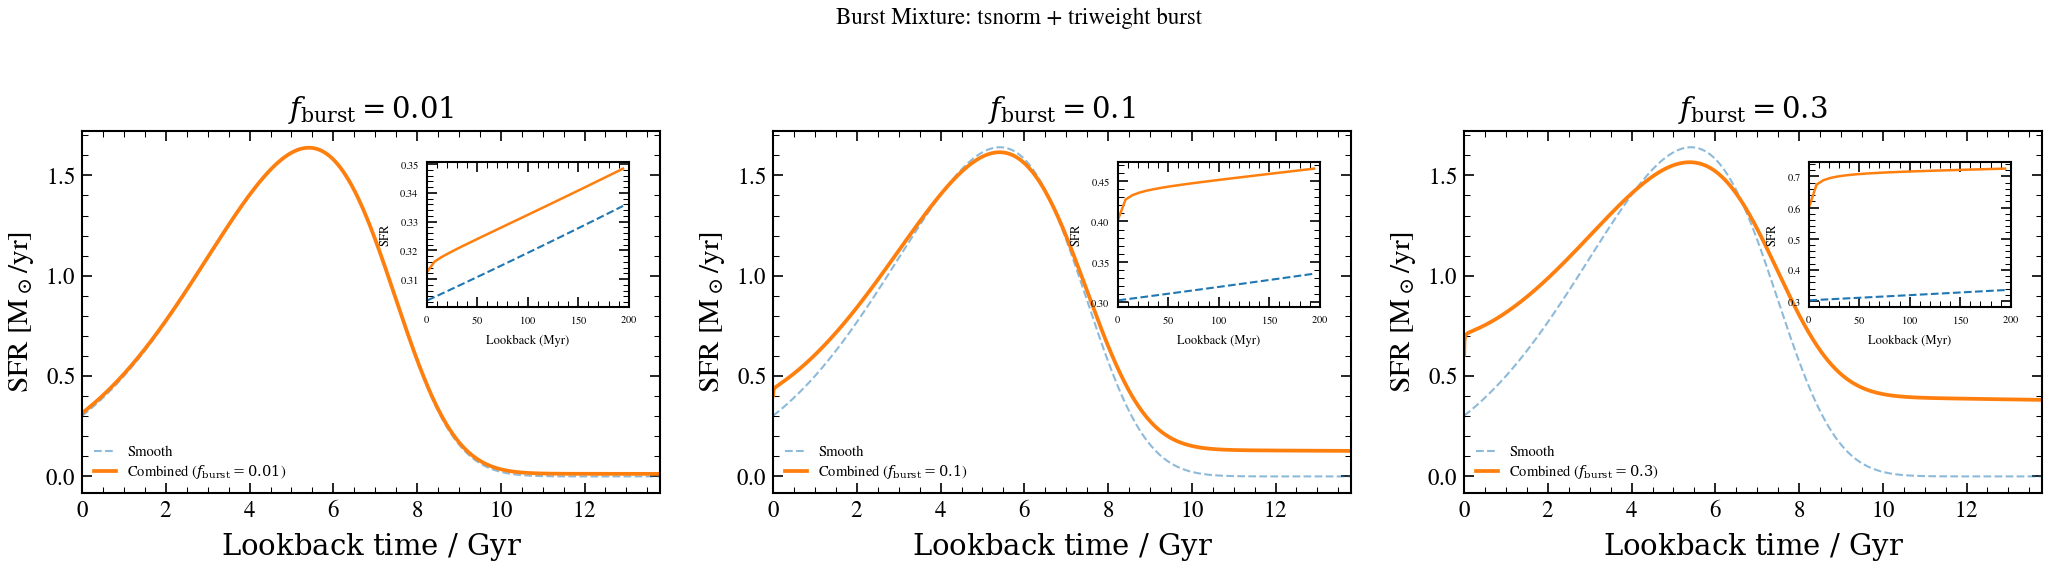

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))

smooth_base = tsnorm(t_yr, log_peak_sfr=0.5, peak_lbt=6e9, width=2e9, skew=0.2, trunc=3.0)
burst_shape = triweight_burst(t_yr, log_tpeak_myr=2.0, log_tmax_myr=2.5)
burst_shape_norm = burst_shape * np.max(smooth_base) / (np.max(burst_shape) + 1e-30)

for f_burst, ax in zip([0.01, 0.1, 0.3], axes, strict=True):
    combined = (1.0 - f_burst) * np.array(smooth_base) + f_burst * np.array(burst_shape_norm)
    ax.plot(
        t_gyr,
        np.array(smooth_base),
        ls="--",
        lw=1,
        color=COLORS["sfh_mean"],
        alpha=0.5,
        label="Smooth",
    )
    ax.plot(
        t_gyr,
        combined,
        lw=1.8,
        color=COLORS["sfh_full"],
        label=f"Combined ($f_{{\\rm burst}}={f_burst}$)",
    )
    ax.set_xlabel(XLAB_LBT_GYR)
    ax.set_ylabel(r"SFR [M$_\odot$/yr]")
    ax.set_title(rf"$f_{{\rm burst}} = {f_burst}$")
    ax.legend(fontsize=7, frameon=False, loc="lower left")
    ax.set_xlim(0.0, float(t_gyr[-1]))
    add_multi_sfh_inset(
        ax,
        t_gyr,
        [np.array(smooth_base), combined],
        colors=[COLORS["sfh_mean"], COLORS["sfh_full"]],
        linestyles=["--", "-"],
        lws=[1.0, 1.2],
        ylabel="SFR",
    )

fig.suptitle("Burst Mixture: tsnorm + triweight burst", y=1.02, fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_composition_burst.png"), bbox_inches="tight")
plt.show()

### 4.3 Field Modulation: tsnorm $\times \exp(x(t) - K(0)/2)$

Multiple GP realizations showing how burstiness modulates the smooth SFH.

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/88580055.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


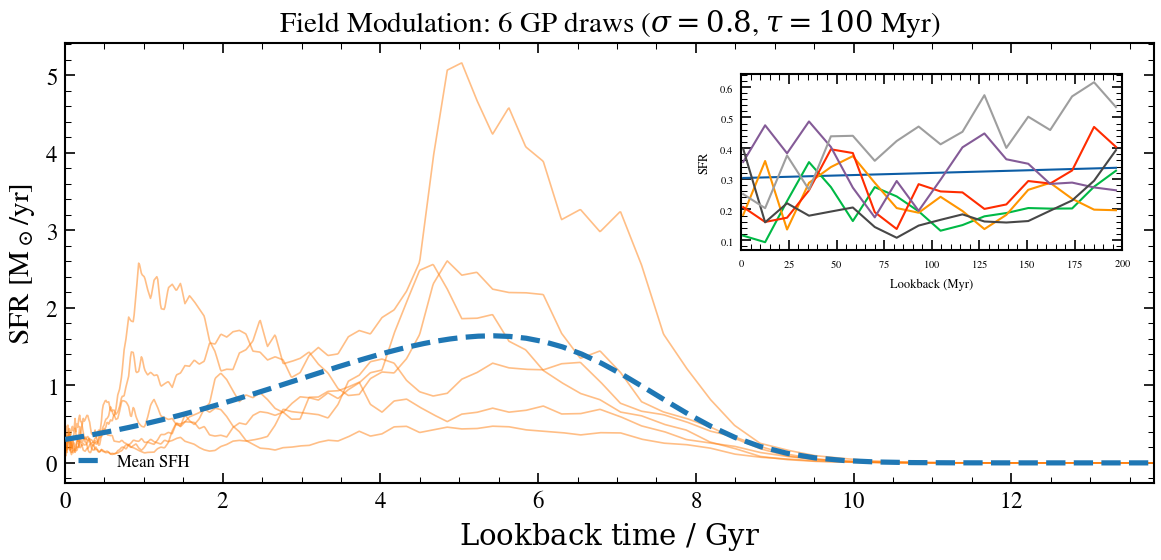

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))

mean_base = tsnorm(ages_yr, log_peak_sfr=0.5, peak_lbt=6e9, width=2e9, skew=0.2, trunc=3.0)
sigma_field = 0.8
tau_field_yr = 100e6
sqrt_p_field = compute_sqrt_power_drw(N_GRID, d_log_age, sigma_field, tau_field_yr)
k0_half_field = float(drw_variance(sigma_field)) / 2.0

mean_base_lin = _sfh_on_lin_grid(mean_base)
ax.plot(
    ages_gyr_lin,
    mean_base_lin,
    color=COLORS["sfh_mean"],
    lw=2.5,
    ls="--",
    label="Mean SFH",
    zorder=5,
)

field_draws_lin = []
for i in range(6):
    key_i = jax.random.PRNGKey(100 + i)
    gp_i = generate_gp_fourier(key_i, sqrt_p_field, N_GRID)
    full_i = mean_base * jnp.exp(gp_i - k0_half_field)
    fl = _sfh_on_lin_grid(full_i)
    field_draws_lin.append(fl)
    ax.plot(ages_gyr_lin, fl, lw=0.8, alpha=0.5, color=COLORS["sfh_full"])

ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"SFR [M$_\odot$/yr]")
ax.set_title(
    rf"Field Modulation: 6 GP draws ($\sigma={sigma_field}$, $\tau={int(tau_field_yr / 1e6)}$ Myr)"
)
ax.legend(fontsize=8, frameon=False, loc="lower left")
ax.set_xlim(0.0, float(ages_gyr_lin[-1]))
add_multi_sfh_inset(ax, ages_gyr_lin, [mean_base_lin, *field_draws_lin], ylabel="SFR")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_composition_field.png"), bbox_inches="tight")
plt.show()

## 5. Chemical Evolution

The closed-box / leaky-box model derives $Z(t)$ from the SFH:
$Z(t) = y_{\rm eff} \cdot \ln(1 / f_{\rm gas}(t))$
where $y_{\rm eff} = y / (1 + \eta)$.

### 5.1 Closed-box vs Leaky-box

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_5649/3058464374.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


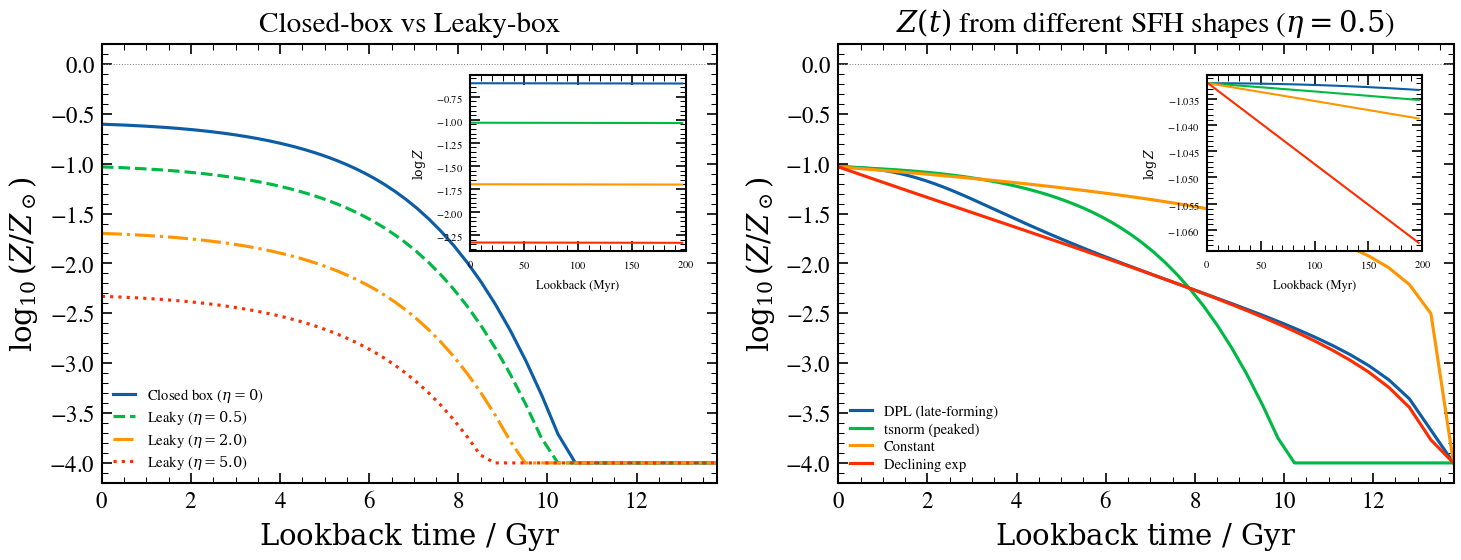

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# Use a tsnorm SFH for the chemical evolution demo
sfr_chem = np.array(
    tsnorm(ages_yr, log_peak_sfr=0.5, peak_lbt=6e9, width=2e9, skew=0.2, trunc=3.0)
)

# Panel A: Closed-box (eta=0) vs leaky-box (eta > 0)
ax = axes[0]
eta_specs = [
    (0.0, "-", "Closed box ($\\eta=0$)"),
    (0.5, "--", "Leaky ($\\eta=0.5$)"),
    (2.0, "-.", "Leaky ($\\eta=2.0$)"),
    (5.0, ":", "Leaky ($\\eta=5.0$)"),
]
series_z_eta = []
for eta, ls, label in eta_specs:
    logz = closed_box_metallicity(ages_yr, jnp.array(sfr_chem), yield_y=0.03, eta_outflow=eta)
    z_lin = _sfh_on_lin_grid(logz)
    series_z_eta.append(z_lin)
    ax.plot(ages_gyr_lin, z_lin, lw=1.5, ls=ls, label=label)
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"$\log_{10}(Z/Z_\odot)$")
ax.set_title("Closed-box vs Leaky-box")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.axhline(0.0, color="grey", lw=0.5, ls=":")
ax.set_xlim(0.0, float(ages_gyr_lin[-1]))
add_multi_sfh_inset(ax, ages_gyr_lin, series_z_eta, ylabel=r"$\log Z$")

# Panel B: Effect of different SFH shapes on Z(t)
ax = axes[1]
sfh_set = {
    "DPL (late-forming)": np.array(dpl(ages_yr, alpha=3.0, beta=1.0, tau=3e9, log_peak_sfr=0.5)),
    "tsnorm (peaked)": np.array(
        tsnorm(ages_yr, log_peak_sfr=0.5, peak_lbt=6e9, width=2e9, skew=0.2, trunc=3.0)
    ),
    "Constant": np.array(constant_sfh(ages_yr, log_sfr=0.0)),
    "Declining exp": np.array(exponential_sfh(ages_yr, log_peak_sfr=0.5, tau=3e9)),
}

series_z_shape = []
for name, sfr_i in sfh_set.items():
    logz_i = closed_box_metallicity(ages_yr, jnp.array(sfr_i), yield_y=0.03, eta_outflow=0.5)
    z_lin = _sfh_on_lin_grid(logz_i)
    series_z_shape.append(z_lin)
    ax.plot(ages_gyr_lin, z_lin, lw=1.5, label=name)
ax.set_xlabel(XLAB_LBT_GYR)
ax.set_ylabel(r"$\log_{10}(Z/Z_\odot)$")
ax.set_title(r"$Z(t)$ from different SFH shapes ($\eta=0.5$)")
ax.legend(fontsize=7, frameon=False, loc="lower left")
ax.axhline(0.0, color="grey", lw=0.5, ls=":")
ax.set_xlim(0.0, float(ages_gyr_lin[-1]))
add_multi_sfh_inset(ax, ages_gyr_lin, series_z_shape, ylabel=r"$\log Z$")

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "18_chemical_evolution.png"), bbox_inches="tight")
plt.show()

## 6. Summary Table

| Model | Type | Free params | Key reference |
|-------|------|-------------|---------------|
| `delayed_tau` | Parametric | 2 ($\tau$, norm) | Classic |
| `dexp` | Parametric | 3 (log_peak, $\tau$, start) | Classic |
| `dpl` | Parametric | 4 ($\alpha$, $\beta$, $\tau$, log_peak) | Carnall+2018 |
| `tsnorm` | Parametric | 5 (peak, width, skew, trunc, log_peak) | Bellstedt+2020 |
| `snorm` | Parametric | 4 (peak, width, skew, log_peak) | Robotham+2020 |
| `norm` | Parametric | 3 (peak, width, log_peak) | Gaussian |
| `lnorm` | Parametric | 3 (peak, width, log_peak) | Log-normal |
| `const` | Parametric | 1-3 (log_sfr, start, end) | Constant |
| `exp` | Parametric | 2-3 (log_peak, $\tau$, start) | Declining tau |
| `triweight_burst` | Parametric | 2 (log_tpeak, log_tmax) | Zacharegkas+2025 |
| `continuity` | Non-parametric | 7 (log_mass + 6 ratios) | Leja+2019 |
| `dirichlet` | Non-parametric | 7 (log_mass + 6 z_frac) | Leja+2017 |
| `field` (DRW) | Stochastic | 2 + $N_{\rm grid}$ ($\sigma$, $\tau$, $\xi$) | Munoz+2026 |
| `field` (Matern) | Stochastic | 3 + $N_{\rm grid}$ (var, $\ell$, $\nu$, $\xi$) | Generalized |
| `field` (Ext. Reg.) | Stochastic | 5 + $N_{\rm grid}$ | Tacchella+2020 |
| `burst` (mixture) | Composition | 3 (log_fburst, log_tpeak, log_tmax) | Zacharegkas+2025 |

**Composition rules:**
- At least one additive model required.
- At most one burst (mixture) and one field (modulator).
- Example: `["tsnorm", "burst", "field"]` = smooth backbone + burst + GP stochasticity.

In [21]:
print("SFH gallery notebook complete.")

SFH gallery notebook complete.
